# Plate ID Assignment: Loading Data from Files

When working with paleogeographic reconstructions, it's common to have a list of modern-day coordinates (longitude, latitude). For example, fossil find locations, volcanic hotspots, or sampling stations.

If we want to **reconstruct these points to past geological times**, we first need to know:

1. Which tectonic plate each point belongs to.
2. The valid time range for that point’s position.

This tutorial shows how to:
- Read a set of polyline data from a file
- Assign plate IDs and valid time periods to those points.
- Save the results into a GPML file that you can open in `pyGPlates`.

### Setup

Let's begin by importing the required packages!

In [31]:
# Ensure you have the required packages installed:
# Run `pip install pygplates gplately cartopy matplotlib` if needed.

from plate_model_manager import PlateModelManager
import pygplates
import matplotlib.pyplot as plt
import gplately
import cartopy.crs as ccrs

We need two things before we get started:

- A rotation model → tells the software how plates have moved over geological time.

- Static polygons → tells it which plate each location belongs to today (present-day geometry).

Without these two, the `GPlately` has no idea how your locations relate to plates, or how to move them backwards in time.

> NOTE: Using `PlateModelManager` means you don’t need to hardcode file paths, but you can also manually specify the .rot & .gpml filepaths if needed!

In [32]:
# Create a Plate Model Manager
pm_manager = PlateModelManager()

# Load & download model data into the path specified by 'data_dir'
# To load a specific model, you can specify the model name
muller2019_model = pm_manager.get_model("Muller2019", data_dir="../../data/plate-model-repo")

# Get the rotation model and static polygons from the loaded model
# Alternatively, specify the paths directly if you have them
rotation_model = muller2019_model.get_rotation_model()
static_polygons_filename = muller2019_model.get_static_polygons()

# Define input filename
input_polylines_filename = '../../data/input_polylines.txt'

# Define output filename
output_polylines_filename = '../../data/polylines_with_plate_ids.gpml'

An example input text file (in longitude/latitude order) looks like:

We first parse the file and read in a series of coordinate pairs that define connected line segments. After defining this XY data, we loop through each polyline and:

- Create a `PolylineOnSphere` i.e. pyGPlates’ internal representation of a geographic point.

- Create a Feature i.e. a pyGPlates object that can store geometry plus metadata.

- Attach the polyline geometry and any descriptive attributes (e.g., name or type of feature).

- Add the feature to a list (`polyline_features`).

This process converts our raw coordinate lists into objects that `pyGPlates` can recognize and manipulate.

The polyline data in the input file represents a global sample of major mountain ranges.

In [33]:
# A function that creates a polyline feature from some points.
def add_polyline_feature_from_points(polyline_features, points, line_number):

    # If have no points then nothing to do.
    if not points:
        return

    # Need at least two points for a polyline.
    if len(points) >= 2:
        polyline = pygplates.PolylineOnSphere(points)

        polyline_feature = pygplates.Feature()
        polyline_feature.set_geometry(polyline)

        polyline_features.append(polyline_feature)

    else:   # If only one point then warning.
        print('Line %d: Ignoring polyline - polyline has only one point.' % (line_number-1))

    # Clear points list for next feature.
    del points[:]


# Parse the input polylines text file containing groups of lon/lat points per line.
polyline_features = []
polyline_points = []
with open(input_polylines_filename, 'r') as input_polylines_file:
    for line_number, line in enumerate(input_polylines_file):

        # Make line number 1-based instead of 0-based.
        line_number = line_number + 1

        # See if line begins with '>'.
        # This is was separates groups of points into polylines.
        if line.strip().startswith('>'):

            # Generate the previous polyline feature.
            add_polyline_feature_from_points(polyline_features, polyline_points, line_number)
            continue

        line_string_list = line.split()

        # Need at least two strings per line (for latitude and longitude).
        if len(line_string_list) < 2:
            print('Line %d: Ignoring point - line does not have at least two white-space separated strings.' % line_number)
            continue

        # Attempt to convert each string into a floating-point number.
        try:
            # Use GMT (lon/lat) order.
            lon = float(line_string_list[0])
            lat = float(line_string_list[1])
        except ValueError:
            print('Line %d: Ignoring point - cannot read lon/lat values.' % line_number)
            continue

        # Create a pyGPlates point from the latitude and longitude
        # and add it to our list of points.
        polyline_points.append(pygplates.PointOnSphere(lat, lon))

    # If we have any points leftover then generate the last polyline feature.
    add_polyline_feature_from_points(polyline_features, polyline_points, line_number)

### Assigning Plate IDs!

Now, we assign plate IDs to the polyline features! Here's how it works:

- Each polyline’s geometry (`polyline_features`) is compared against the static polygons representing present-day plate boundaries.

- The rotation model is used to determine how these polygons relate to plates through time.

- The `properties_to_copy` argument tells `pyGPlates` which additional attributes to attach (in this case, the reconstruction plate ID and valid time period).

The result is a new list of assigned polyline features (`assigned_polyline_features`) that now carry plate information, ready for reconstruction or export to GPML for visualization.

In [34]:
# Use the static polygons to assign plate IDs and valid time periods.
# Each polyline feature is partitioned into one or more of the static polygons and assigned their
# reconstruction plate IDs and valid time periods.

assigned_polyline_features = pygplates.partition_into_plates(
    static_polygons_filename,
    rotation_model,
    polyline_features,
    properties_to_copy = [
        pygplates.PartitionProperty.reconstruction_plate_id,
        pygplates.PartitionProperty.valid_time_period])

Next, we:

- Wrap the assigned polyline features into a `FeatureCollection` i.e. pyGPlates’ container for handling multiple geometries together.

- Write the collection to a `.gpml` file using `.write()`. GPML (GPlates Markup Language) stores the reconstructed geometries along with metadata such as plate IDs and valid time periods.

Once saved, you can open this `.gpml` file in GPlately to visualise the mountain range polylines with their assigned plate IDs and reconstruction times, allowing you to see how each range has shifted with tectonic motion over geological time.

In [35]:
# Write the assigned polyline features to the output GPML file (ready for use in GPlates).
assigned_polyline_feature_collection = pygplates.FeatureCollection(assigned_polyline_features)
assigned_polyline_feature_collection.write(output_polylines_filename)


print(f"Saved results to {output_polylines_filename}")

Saved results to ../../data/polylines_with_plate_ids.gpml


### Visualising the Effect of Plate IDs

Now let's see the difference assigning plate IDs makes for polyline features representing global mountain ranges. We'll reconstruct the ranges to 100 million years ago and compare:

1. Without plate IDs: Polylines remain in their present-day positions (geologically inaccurate!).

2. With plate IDs: Polylines move with their respective tectonic plates, showing where the mountain ranges would have been 100 million years ago (geologically accurate!).

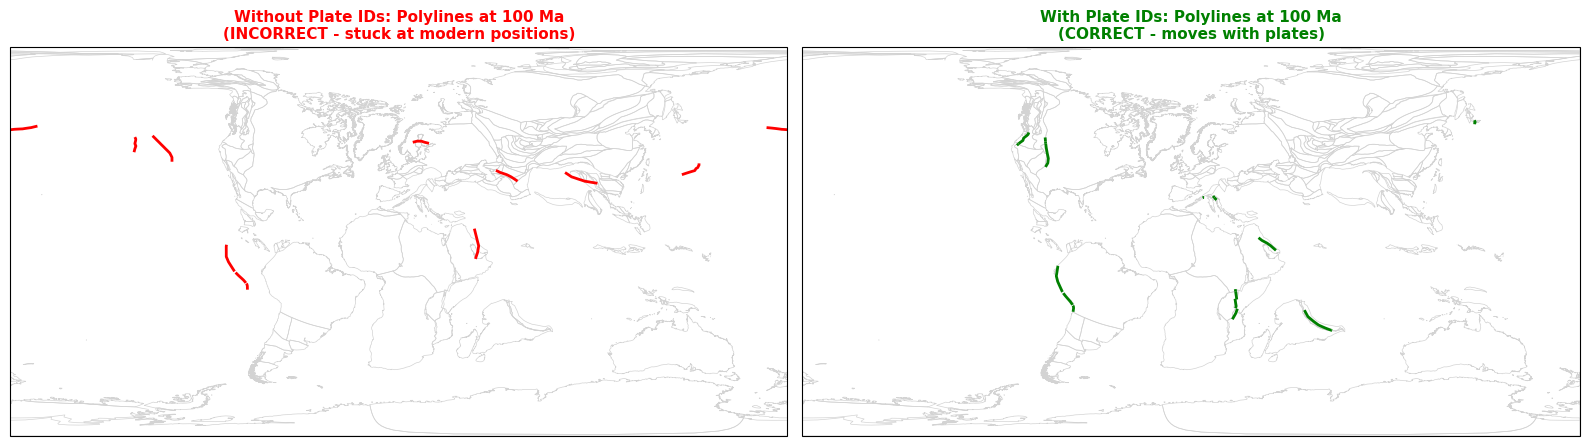

In [36]:
# --------------------------------------------------
# Reconstruct at chosen geological time
# --------------------------------------------------
reconstruction_time = 100  # Ma
model = gplately.PlateReconstruction(rotation_model, static_polygons_filename)
gplot = gplately.PlotTopologies(model, time=reconstruction_time)

# Load features for both cases
original_features = pygplates.FeatureCollection(polyline_features)
reconstructed_original = model.reconstruct(original_features, to_time=reconstruction_time)

assigned_features = pygplates.FeatureCollection(output_polylines_filename)
reconstructed_assigned = model.reconstruct(assigned_features, to_time=reconstruction_time)

# Coastlines
coastlines = muller2019_model.get_layer("Coastlines")
reconstructed_coastlines = model.reconstruct(coastlines, to_time=reconstruction_time)

# --------------------------------------------------
# Plot comparison
# --------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8),
                               subplot_kw={"projection": ccrs.PlateCarree()})

# --- Left plot: Without plate IDs ---
gplot.plot_feature(ax1, reconstructed_coastlines, color="lightgray", linewidth=0.5)
gplot.plot_feature(ax1, reconstructed_original, color="red", linewidth=2)
ax1.set_title(f"Without Plate IDs: Polylines at {reconstruction_time} Ma\n(INCORRECT - stuck at modern positions)",
              fontsize=11, fontweight="bold", color="red")
ax1.set_global()

# --- Right plot: With plate IDs ---
gplot.plot_feature(ax2, reconstructed_coastlines, color="lightgray", linewidth=0.5)
gplot.plot_feature(ax2, reconstructed_assigned, color="green", linewidth=2)
ax2.set_title(f"With Plate IDs: Polylines at {reconstruction_time} Ma\n(CORRECT - moves with plates)",
              fontsize=11, fontweight="bold", color="green")
ax2.set_global()

plt.tight_layout()
plt.show()